In [1]:
import loompy as lp
import pandas as pd

from ctxcore.genesig import openfile

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pdir = "/dcs04/lieber/marmaypag/spatialDLPFC_mdd_bpd_LIBD4100/spatialDLPFC_mdd_bpd/"
REGULON_PATH = pdir+"processed-data/10_SCENIC/AUCell_regulons/"
REGULON_TYPE = "regulons-weighted-top20"

In [3]:
def extract_aucell(cluster):
    
    lf = lp.connect(REGULON_PATH+"spe-n119_seurat-label-"+cluster+"_13162-genes_no-lowUMI_logcounts_"+REGULON_TYPE+"_AUCell-fixed-thold-05.loom", mode='r+', validate=False)
    auc_mtx = pd.DataFrame(lf.ca.RegulonsAUC, index=lf.ca.CellID)
    cell_mtx = pd.DataFrame({"seurat_label": lf.ca.seurat_label, "smoothed_k9_1663": lf.ca.smoothed_k9_1663, #"custom_cluster": cluster,
                             "sex": lf.ca.sex, "condition": lf.ca.condition, "nGene": lf.ca.nGene, "nUMI": lf.ca.nUMI}, index=lf.ca.CellID)
    lf.close()
    
    #signature_column_names = list(auc_mtx.select_dtypes('number').columns)
    #signature_column_names = list(map(lambda s: s[12:], signature_column_names))
    #auc_mtx.columns = signature_column_names
    
    return auc_mtx, cell_mtx

In [4]:
auc_mv, cell_mv = extract_aucell("Micro.Vasc")
auc_ast, cell_ast = extract_aucell("Astro")
auc_l23, cell_l23 = extract_aucell("L2.3")
auc_l4, cell_l4 = extract_aucell("L4")
auc_inh, cell_inh = extract_aucell("Inhb")
auc_l5, cell_l5 = extract_aucell("L5")
auc_l6, cell_l6 = extract_aucell("L6")
auc_wm, cell_wm = extract_aucell("Oligo")

In [5]:
auc_all = pd.concat([auc_mv, auc_ast, auc_l23,
                     auc_l4, auc_inh, auc_l5, auc_l6, auc_wm])
cell_all = pd.concat([cell_mv, cell_ast, cell_l23,
                      cell_l4, cell_inh, cell_l5, cell_l6, cell_wm])

In [6]:
joined_all = pd.concat([auc_all, cell_all], axis=1)
joined_all.shape

(513200, 37)

In [7]:
joined_all.to_csv(pdir+"processed-data/10_SCENIC/spe-n119_13162-no-lowUMI_logcounts_"+REGULON_TYPE+"_AUCell.csv")

In [8]:
import pickle
with open(pdir+'processed-data/10_SCENIC/spe-n119_13162-no-lowUMI_logcounts.'+REGULON_TYPE+'.dat', 'rb') as file:
    regulons = pickle.load(file)

In [10]:
reg_df = pd.DataFrame({"TF": [item.transcription_factor for item in regulons],
                       #"dir": ["promoter" if "activating" in item.context else "enhancer" for item in regulons],
                       "dir": ["activating" if "activating" in item.context else "repressing" for item in regulons],
                       "set_size": [len(item) for item in regulons],
                      "set_str": ['/' .join(list(item.genes)) for item in regulons]})

In [11]:
reg_df

,TF,dir,set_size,set_str
0,ARX,activating,11,SP9/MYO5B/KCNS3/LHX6/TAC1/AKAIN1/ARX/NXPH1/GAD...
1,ATF3,activating,17,ZIC4/RRAD/EMP1/VWF/MUSTN1/IFITM1/ITGA5/ADAMTS1...
2,BCL6,activating,7,CHI3L1/ADAM28/HK2/BCL6/FAM189A2/CD44/MTRNR2L1
3,CEBPB,activating,11,NEXN/CP/CYP1B1/S100A8/CD14/CEBPB/S100A9/DDX60/...
4,CEBPD,activating,31,MT1X/MT1A/GPR4/HAMP/IFITM3/MT1M/EDN1/TGM2/CDKN...
5,CUX2,activating,10,FREM3/LINC00507/RCN1/RASGRF2/EPHA6/NEUROD1/GRB...
6,DLX1,activating,18,NR2F2/DLX6-AS1/SOX1/DLX2/PENK/DLX5/DLX6/DLX1/E...
7,ETS2,activating,13,GLI3/TESPA1/LMO4/RGS4/ENC1/GAP43/RCAN2/ZNF682/...
8,FOS,activating,53,ATF3/BTG2/DUSP1/NR4A1/HSPA1B/RGS1/SOCS3/EGR1/N...
9,FOSB,activating,9,NPAS4/EGR4/INHBA/EGR1/FOS/RGS2/BDNF/FOSB/GADD45B


In [12]:
reg_df.to_csv(pdir+"processed-data/10_SCENIC/spe-n119_13162-no-lowUMI_logcounts_"+REGULON_TYPE+"_merged.csv")

In [13]:
transfer_bright = {'Micro.Vasc': "#911223", 'Astro': "#cfa45c", 'L2.3': "#088F8F", 'L4': "#c2cfcf",
                   'Inhb': "#9377AC", 'L5': "#ddc94e", 'L6': "#E45C5F", 'Oligo': "#D1C4B0"}
smoothed_bright = {'Vasc': "#911223", 'L1': "#cfa45c", 'L2': "#5D9940", 'L3.4': "#5095CD",
                  'GABA': "#9377AC", 'L5': "#ddc94e", 'L6': "#E45C5F", 'WM': "#D1C4B0"}

In [14]:
joined_precast = joined_all.loc[-joined_all['smoothed_k9_1663'].isin(['Vasc','GABA'])]
joined_precast.shape

(508372, 37)

In [14]:
auc_all.columns

Index(['ARX(+)', 'ATF3(+)', 'BCL6(+)', 'CEBPB(+)', 'CEBPD(+)', 'CUX2(+)',
       'DLX1(+)', 'ETS2(+)', 'FOS(+)', 'FOSB(+)', 'GTF2I(+)', 'JUN(+)',
       'JUND(+)', 'KLF2(+)', 'KLF4(+)', 'LHX6(+)', 'MAFF(+)', 'NPAS4(+)',
       'NR2F2(+)', 'SOX10(+)', 'SOX2(+)', 'SOX8(+)', 'SOX9(+)', 'THRA(+)',
       'ZBTB7A(+)'],
      dtype='object')

In [15]:
sns.set_context("notebook", font_scale=.7)

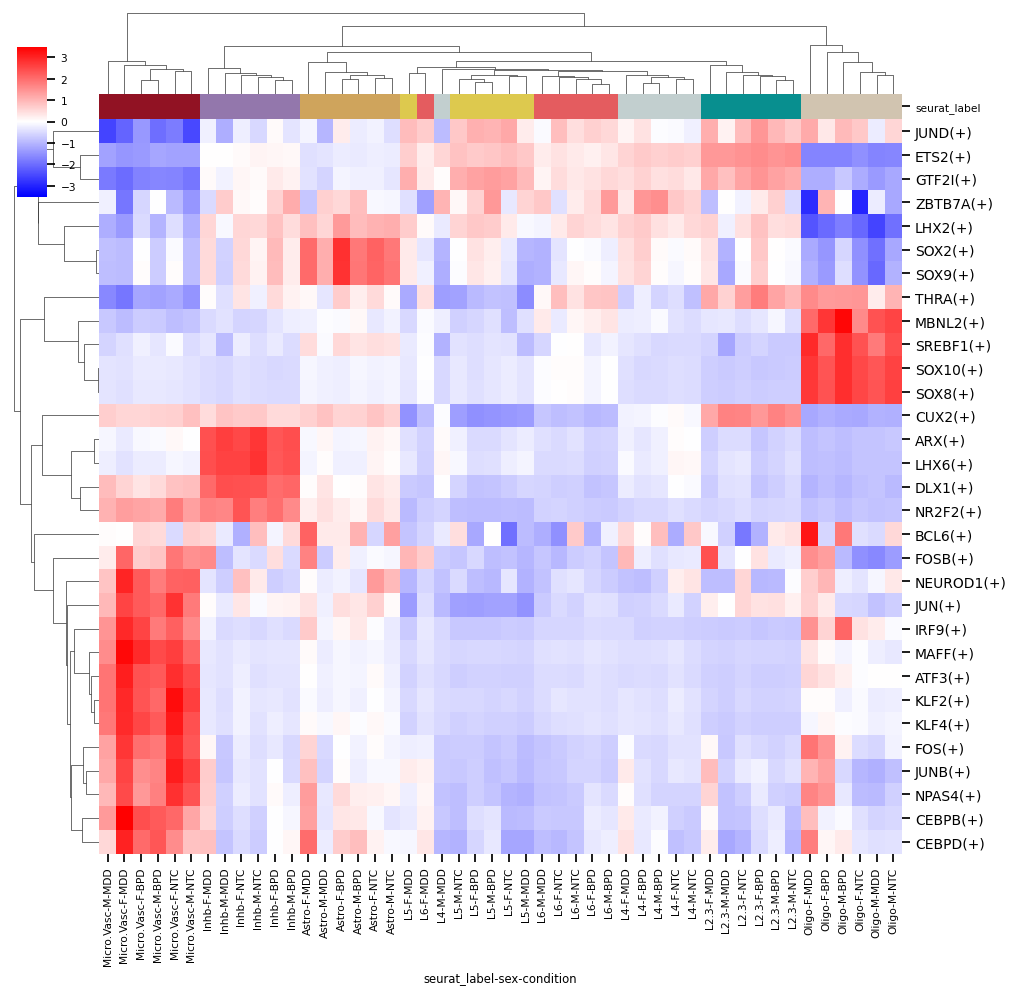

In [29]:
df_scores = joined_all[list(auc_all.select_dtypes('number').columns)+['seurat_label','sex','condition']]
df_means = df_scores.groupby(by=['seurat_label','sex','condition']).mean()

colors_df = pd.DataFrame(index=df_means.index)
colors_df['seurat_label'] = [x[0] for x in df_means.index]
row_colors = colors_df['seurat_label'].map(transfer_bright)

hmp = sns.clustermap(df_means.T, z_score='row', col_colors=row_colors, dendrogram_ratio=.1,
               cmap='bwr', vmin=-3.5, vmax=3.5,
              cbar_pos=(0.02, 0.8, 0.03, 0.15))
hmp.ax_heatmap.set_yticklabels(hmp.ax_heatmap.get_ymajorticklabels(), fontsize = 10)

hmp.figure.savefig(pdir+'plots/10_SCENIC/spe-n119_13162-no-lowUMI_logcounts_'+REGULON_TYPE+'_AUCell-seurat-pc30.pdf')

plt.show()

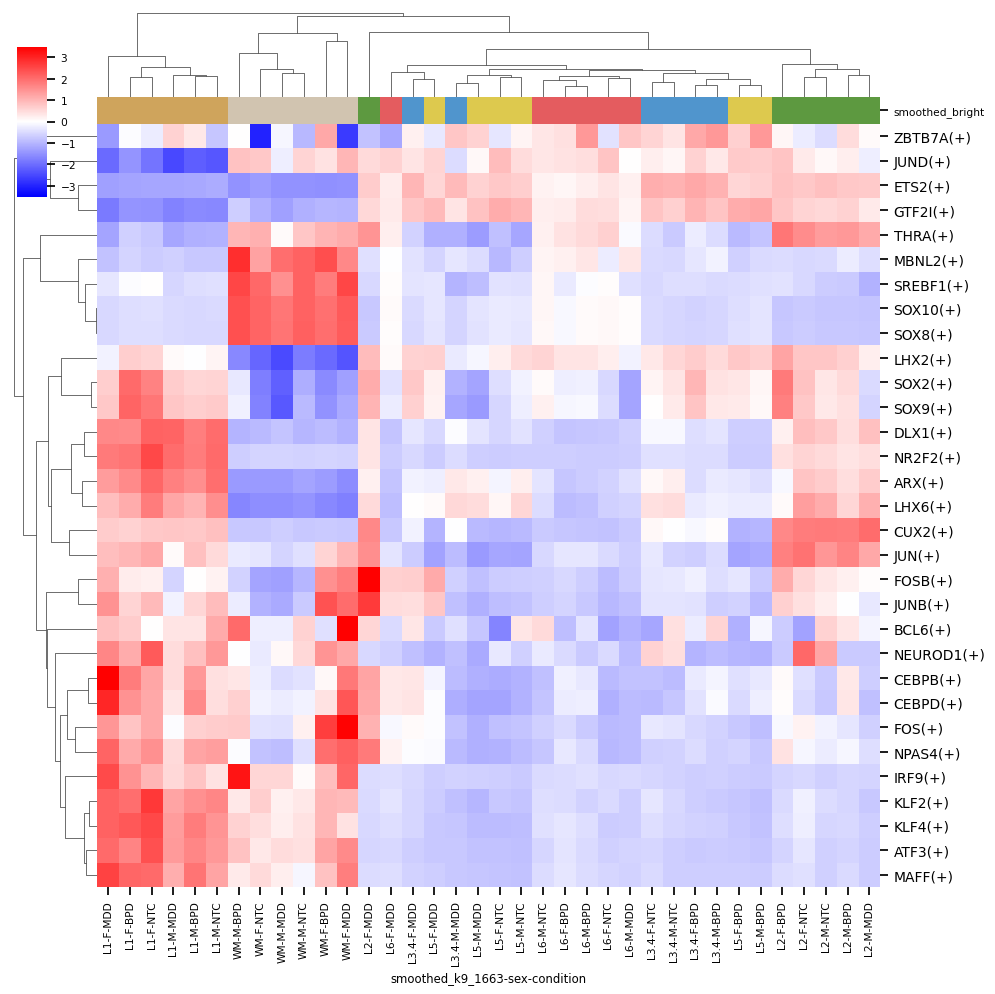

In [30]:
df_scores = joined_all[list(auc_all.select_dtypes('number').columns)+['smoothed_k9_1663','sex','condition']]
df_scores = df_scores.loc[-df_scores['smoothed_k9_1663'].isin(['Vasc','GABA'])]
df_means = df_scores.groupby(by=['smoothed_k9_1663','sex','condition']).mean()

colors_df = pd.DataFrame(index=df_means.index)
colors_df['smoothed_bright'] = [x[0] for x in df_means.index]
row_colors = colors_df['smoothed_bright'].map(smoothed_bright)

hmp = sns.clustermap(df_means.T, z_score='row', col_colors=row_colors, dendrogram_ratio=.1,
               cmap='bwr', vmin=-3.5, vmax=3.5,
              cbar_pos=(0.02, 0.8, 0.03, 0.15))
hmp.ax_heatmap.set_yticklabels(hmp.ax_heatmap.get_ymajorticklabels(), fontsize = 10)

hmp.figure.savefig(pdir+'plots/10_SCENIC/spe-n119_13162-no-lowUMI_logcounts_'+REGULON_TYPE+'_AUCell-smoothed-k9-1663.pdf')

plt.show()

In [18]:
import numpy as np
auc_corr = np.corrcoef(auc_all.T)
corrDF = pd.DataFrame(auc_corr, index=auc_all.columns, columns= auc_all.columns)
corrDF.head()

,ARX(+),ATF3(+),BCL6(+),CEBPB(+),CEBPD(+),CUX2(+),DLX1(+),ETS2(+),FOS(+),FOSB(+),...,NEUROD1(+),NPAS4(+),NR2F2(+),SOX10(+),SOX2(+),SOX8(+),SOX9(+),SREBF1(+),THRA(+),ZBTB7A(+)
ARX(+),1.000000,-0.007148,0.005970,-0.013286,-0.025897,0.022250,0.387491,-0.047274,-0.008843,0.005777,...,-0.000343,0.008728,0.092254,-0.068971,-0.002542,-0.073117,-0.001210,-0.049413,-0.034713,0.018531
ATF3(+),-0.007148,1.000000,0.052950,0.191300,0.259921,-0.001096,0.043076,-0.235766,0.384987,0.075795,...,0.083963,0.180803,0.055531,0.070423,0.004713,0.064979,0.008949,0.062890,-0.043590,-0.017953
BCL6(+),0.005970,0.052950,1.000000,0.077648,0.123570,0.011329,0.009824,-0.085374,0.089301,-0.001896,...,0.011937,0.036698,0.011777,0.081529,0.087444,0.074370,0.084533,0.090537,0.039269,0.057137
CEBPB(+),-0.013286,0.191300,0.077648,1.000000,0.572166,0.009108,0.011131,-0.164210,0.175426,0.041069,...,0.052579,0.132971,0.083740,0.018369,0.055898,0.012586,0.060354,0.078636,-0.015402,-0.037712
CEBPD(+),-0.025897,0.259921,0.123570,0.572166,1.000000,-0.003008,-0.000701,-0.250587,0.292014,0.105262,...,0.114361,0.259741,0.060046,0.082085,0.197167,0.073190,0.203295,0.211984,0.014726,-0.041097


In [19]:
corrDF.to_csv(pdir+"processed-data/10_SCENIC/spe-n119_13162-no-lowUMI_logcounts_"+REGULON_TYPE+"_AUCell-correlation.csv")

In [22]:
REGULON_TYPE

'regulons-weighted-top20'

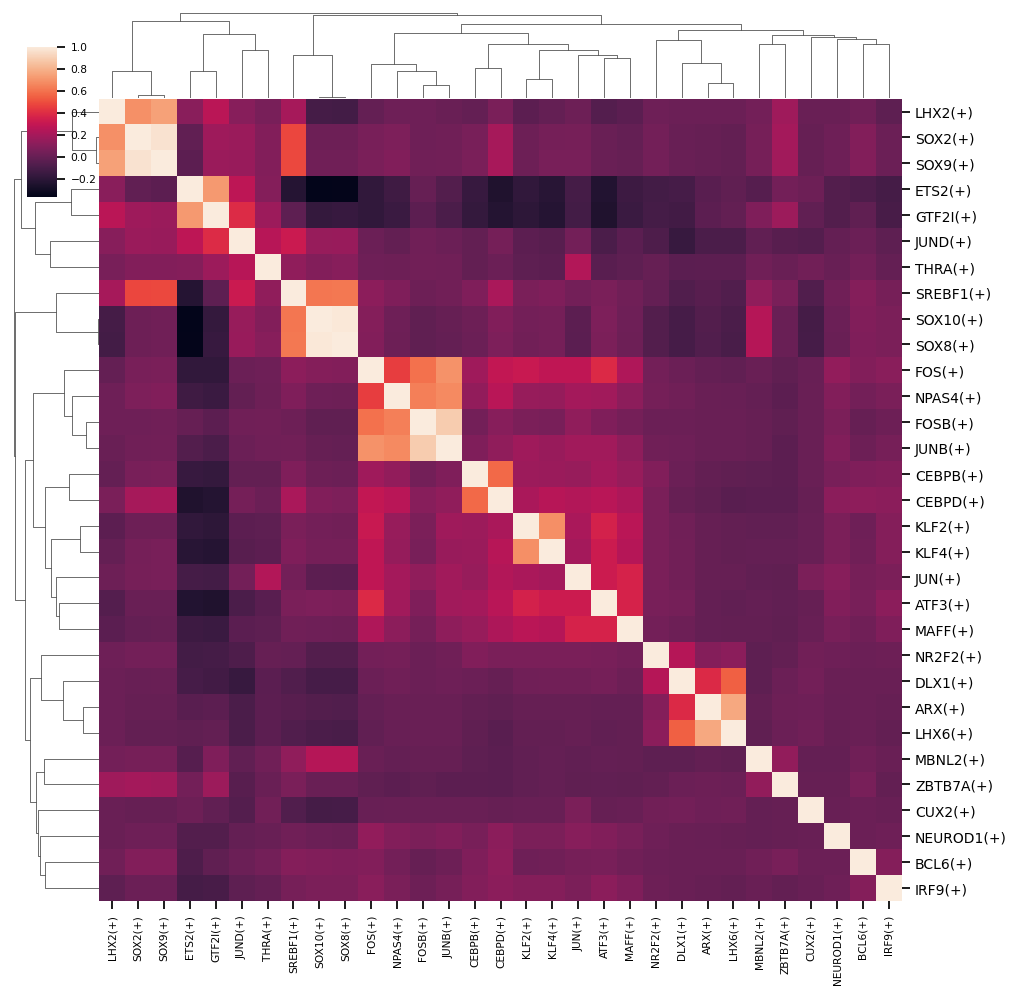

In [28]:
hmp = sns.clustermap(corrDF, dendrogram_ratio=.1,
                    cbar_pos=(0.02, 0.8, 0.03, 0.15))
hmp.ax_heatmap.set_yticklabels(hmp.ax_heatmap.get_ymajorticklabels(), fontsize = 10)

hmp.figure.savefig(pdir+'plots/10_SCENIC/spe-n119_13162-no-lowUMI_logcounts_'+REGULON_TYPE+'_AUCell-correlation.pdf')

plt.show()

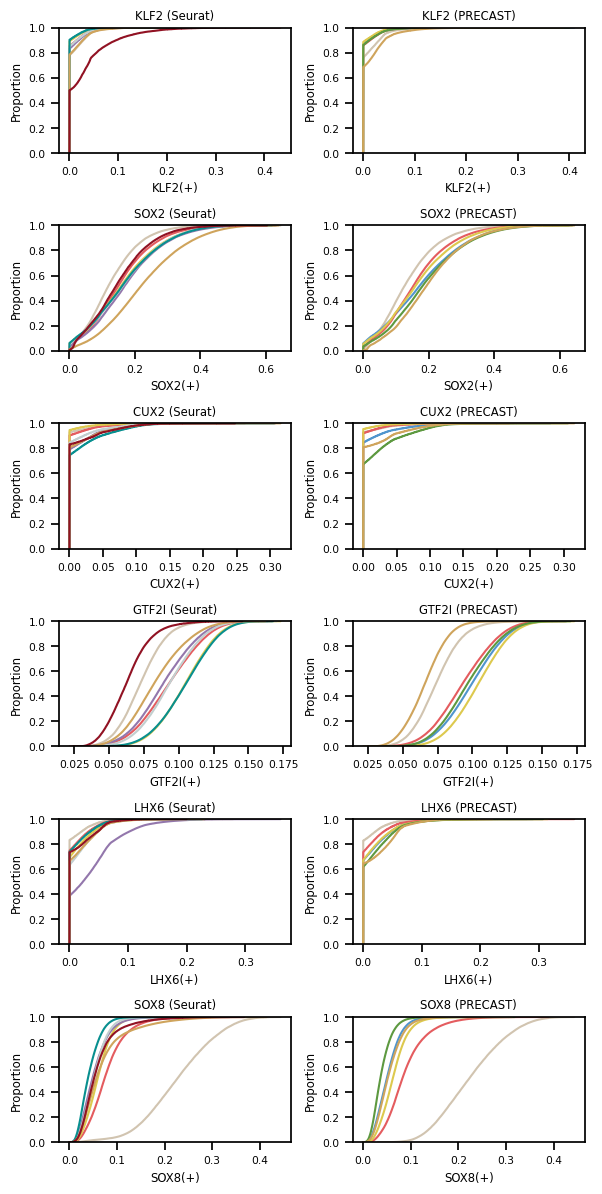

In [33]:
fig, axs = plt.subplots(6, 2, figsize=(6, 12))

axs = axs.flatten()

sns.ecdfplot(data=joined_all, x="KLF2(+)", hue="seurat_label", palette=transfer_bright, 
             legend=False, ax=axs[0])
axs[0].set_title("KLF2 (Seurat)")
sns.ecdfplot(data=joined_precast, x="KLF2(+)", hue="smoothed_k9_1663", palette=smoothed_bright, 
             legend=False, ax=axs[1])
axs[1].set_title("KLF2 (PRECAST)")

sns.ecdfplot(data=joined_all, x="SOX2(+)", hue="seurat_label", palette=transfer_bright, 
             legend=False, ax=axs[2])
axs[2].set_title("SOX2 (Seurat)")
sns.ecdfplot(data=joined_precast, x="SOX2(+)", hue="smoothed_k9_1663", palette=smoothed_bright, 
             legend=False, ax=axs[3])
axs[3].set_title("SOX2 (PRECAST)")

sns.ecdfplot(data=joined_all, x="CUX2(+)", hue="seurat_label", palette=transfer_bright, 
             legend=False, ax=axs[4])
axs[4].set_title("CUX2 (Seurat)")
sns.ecdfplot(data=joined_precast, x="CUX2(+)", hue="smoothed_k9_1663", palette=smoothed_bright, 
             legend=False, ax=axs[5])
axs[5].set_title("CUX2 (PRECAST)")

sns.ecdfplot(data=joined_all, x="GTF2I(+)", hue="seurat_label", palette=transfer_bright, 
             legend=False, ax=axs[6])
axs[6].set_title("GTF2I (Seurat)")
sns.ecdfplot(data=joined_precast, x="GTF2I(+)", hue="smoothed_k9_1663", palette=smoothed_bright, 
             legend=False, ax=axs[7])
axs[7].set_title("GTF2I (PRECAST)")

sns.ecdfplot(data=joined_all, x="LHX6(+)", hue="seurat_label", palette=transfer_bright, 
             legend=False, ax=axs[8])
axs[8].set_title("LHX6 (Seurat)")
sns.ecdfplot(data=joined_precast, x="LHX6(+)", hue="smoothed_k9_1663", palette=smoothed_bright, 
             legend=False, ax=axs[9])
axs[9].set_title("LHX6 (PRECAST)")

sns.ecdfplot(data=joined_all, x="SOX8(+)", hue="seurat_label", palette=transfer_bright, 
             legend=False, ax=axs[10])
axs[10].set_title("SOX8 (Seurat)")
sns.ecdfplot(data=joined_precast, x="SOX8(+)", hue="smoothed_k9_1663", palette=smoothed_bright, 
             legend=False, ax=axs[11])
axs[11].set_title("SOX8 (PRECAST)")

plt.tight_layout()
plt.savefig(pdir+'plots/10_SCENIC/spe-n119_13162-no-lowUMI_logcounts_'+REGULON_TYPE+'_AUCell-layers-ecdf.pdf', 
            bbox_inches='tight')
plt.show()

In [34]:
len(auc_all.columns)

31

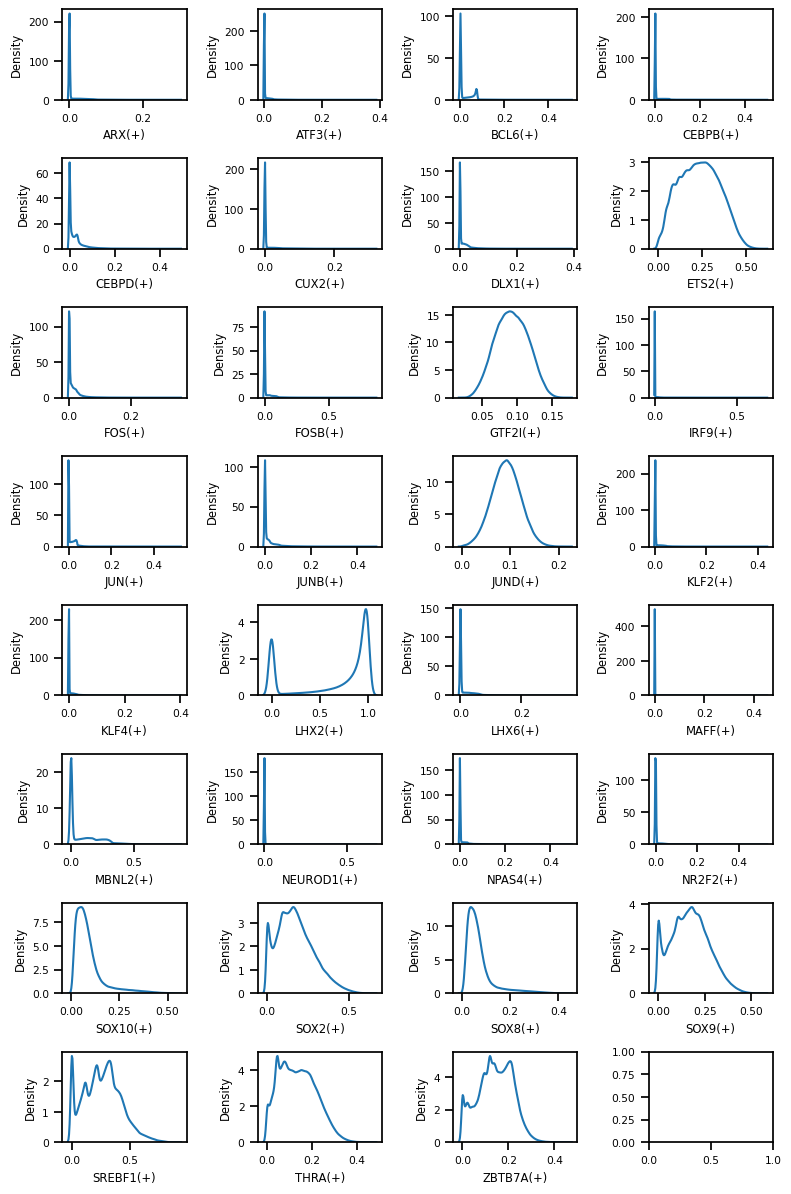

In [37]:
fig, axs = plt.subplots(8, 4, figsize=(8, 12))

axs_flat = axs.flatten()

for i in range(31):
    gene1 = auc_all.columns[i]
    
    sns.kdeplot(data=joined_all, x=gene1, ax=axs_flat[i])

plt.tight_layout()
plt.savefig(pdir+'plots/10_SCENIC/spe-n119_13162-no-lowUMI_logcounts_'+REGULON_TYPE+'_AUCell-density.pdf', 
            bbox_inches='tight')
plt.show()